# 패키지 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import warnings
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import roc_curve, roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings(action='ignore') 

USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda" if USE_CUDA else "cpu")
print("Using Device:", DEVICE)

fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', # ttf 파일이 저장되어 있는 경로
    name='NanumGothic')                        # 이 폰트의 원하는 이름 설정
fm.fontManager.ttflist.insert(0, fe)              # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 18, 'font.family': 'NanumGothic'}) # 폰트 설정

Using Device: cuda


# 데이터 관리

## 데이터 불러오기

In [2]:
df = pd.read_csv('./전체 통합 데이터_전처리 완료.csv')
df.head()

df.drop(['기기명'], inplace=True, axis=1)

# 데이터 전처리

## 결측치 처리

In [3]:
df.drop(['저장시간','형폐시간', '냉각시간'], inplace=True, axis=1)

In [4]:
df.isnull().sum()

기계동작시간        0
이젝터 전진시간      0
이젝터 후진시간      0
사출시간(충진시간)    0
보압시간          0
계량시간          0
사출 최대압력       0
보압절환압력        0
dtype: int64

### 선형 보간법

## 데이터 라벨링

In [5]:
df['IQR이상치개수'] =0
for col in df.columns:
    thirdq, firstq = df[col].quantile(0.75), df[col].quantile(0.25)
    interquartilerange = 1.5 * (thirdq - firstq)
    outlierhigh, outlierlow = interquartilerange + thirdq, firstq - interquartilerange

    outlier_indices = df[(df[col] > outlierhigh) | (df[col] < outlierlow)].index
    for idx in outlier_indices:
        df.loc[idx, 'IQR이상치개수'] += 1
print(df['IQR이상치개수'].value_counts())

IQR이상치개수
0    2049168
1     610387
4     172659
5     162167
2     140640
6      30614
7          4
Name: count, dtype: int64


In [6]:
from scipy.stats import zscore

# z-score 계산
z_scores = np.abs(zscore(df))
# z-score가 3보다 큰 값을 이상치로 판단
df['z-score이상치개수'] = (z_scores > 3).sum(axis=1)
print(df['z-score이상치개수'].value_counts())

z-score이상치개수
0    2822712
1     208389
2      70754
3      59880
4       3884
5         20
Name: count, dtype: int64


In [7]:
df['z_anomaly'] = np.where(df['z-score이상치개수'] < 3, 0, 1)
df['IQR_anomaly'] =np.where(df['IQR이상치개수'] < 5, 0, 1)

In [8]:
df['설비 이상신호'] = np.where((df['z_anomaly']==1) & (df['IQR_anomaly']==1), 1, 0)

In [9]:
normal = df.loc[df['설비 이상신호'] ==0]
abnormal = df.loc[df['설비 이상신호'] ==1]
print('정상 데이터:', len(normal))
print('설비이상 데이터:', len(abnormal))

정상 데이터: 3132964
설비이상 데이터: 32675


In [10]:
normal.drop(['IQR이상치개수','z-score이상치개수','z_anomaly','IQR_anomaly'], axis=1, inplace=True)
abnormal.drop(['IQR이상치개수','z-score이상치개수','z_anomaly','IQR_anomaly'], axis=1, inplace=True)

## 데이터셋 분할

In [11]:
train_Y, test_Y = train_test_split(normal, test_size =0.2, random_state =1)
print('학습 데이터셋 개수:', len(train_Y))
print('테스트 데이터셋 개수:', len(test_Y))

학습 데이터셋 개수: 2506371
테스트 데이터셋 개수: 626593


In [12]:
# 스케일링
scaler = MinMaxScaler()
# 정상 학습데이터 스케일링
normal_train_scaled = scaler.fit_transform(train_Y.iloc[:,:-1])
X_normal_train = pd.DataFrame(data=normal_train_scaled, index=train_Y.iloc[:,:-1].index, columns=train_Y.iloc[:,:-1].columns)
# 정상 학습데이터 y 값 설정
y_normal_train = train_Y.iloc[:,-1]
# 최종 정상 학습데이터
train_Y_normal = pd.concat([X_normal_train, y_normal_train], axis=1)
# 정상 테스트데이터 스케일링
normal_test_scaled = scaler.transform(test_Y.iloc[:,:-1])
X_normal_test = pd.DataFrame(data=normal_test_scaled, index=test_Y.iloc[:,:-1].index, columns=test_Y.iloc[:,:-1].columns)
# 정상 테스트데이터 y 값 설정
y_normal_test = test_Y.iloc[:,-1]
# 최종 정상 테스트데이터
test_Y_normal = pd.concat([X_normal_test, y_normal_test], axis=1)
# 비정상 테스트 데이터 스케일링
abnormal_test_scaled = scaler.transform(abnormal.iloc[:, :-1])
X_abnormal_test = pd.DataFrame(data=abnormal_test_scaled, index=abnormal.iloc[:, :-1].index,
columns=abnormal.iloc[:, :-1].columns)
# y 값 설정
y_abnormal_test = abnormal.iloc[:,-1]
# 최종 비정상 테스트데이터
abnormal_data = pd.concat([X_abnormal_test, y_abnormal_test], axis=1)

In [13]:
X_normal_train
y_normal_train

86406      0
795114     0
2054155    0
505068     0
2794175    0
          ..
836489     0
491263     0
2568076    0
491755     0
128037     0
Name: 설비 이상신호, Length: 2506371, dtype: int64

# 데이터 학습 및 검증

## 데이터 로더 정의

In [14]:
class CustomDataset(Dataset):
    def __init__(self, trainDF):
        self.df = trainDF

        self.inp = trainDF.values
        self.outp = trainDF.values
    def __len__(self):
		# 가지고 있는 데이터셋의 길이를 반환한다.
        return len(self.inp) # 1314
    def __getitem__(self,idx):
        inp = torch.FloatTensor(self.inp[idx])
        outp = torch.FloatTensor(self.outp[idx])
        return inp, outp # 해당하는 idx(인덱스)의 input과 output 데이터를 반환한다.

In [15]:
train_x, test_x = train_test_split(X_normal_train, test_size =0.2, random_state =1)

In [16]:
train_dataset = CustomDataset(train_x)
train_val_dataset = CustomDataset(test_x)
train_dataloader = DataLoader(train_dataset, batch_size=512, shuffle=True)
train_val_dataloader = DataLoader(train_dataset, batch_size=512)

## Autoencoder

### Model Define

In [22]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.channel_num_in = 8

        self.encoder = nn.Sequential(
            nn.Linear(self.channel_num_in, 8),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.BatchNorm1d(4),
            nn.ReLU(),
            nn.Linear(4, 2),
            nn.BatchNorm1d(2),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(2, 4),
            nn.BatchNorm1d(4),
            nn.ReLU(),
            nn.Linear(4, 8),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Linear(8, self.channel_num_in),
            nn.BatchNorm1d(self.channel_num_in),
            nn.ReLU(),
            
        )

    def forward(self, x):
        f = self.encoder(x)
        output = self.decoder(f)
        return output

In [23]:
from torchviz import make_dot

model = Autoencoder()
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=8, out_features=4, bias=True)
    (4): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=4, out_features=2, bias=True)
    (7): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=4, out_features=8, bias=True)
    (4): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=8, bias=True)
    (7): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, tra

### Model Train

In [24]:
model = Autoencoder().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) 
# Adam()을 최적화함수로 사용합니다. Adam은 SGD의 변형함수이며 학습중인 기울기를 참고하여 학습 속도를 자동으로 변화시킵니다.
criterion = nn.MSELoss() #원본값과 디코더에서 나온 값의 차이를 계산하기 위해 평균제곱오차(Mean Squared Loss) 오차함수를 사용합니다.
num_epochs = 100

In [25]:
model.train(True)
best_model = None
best_loss = float('inf')
increasing_loss_count = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_idx, (data, targets) in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        data = data.to(DEVICE)
        targets = targets.to(DEVICE)
        outputs = model(data)
        loss = criterion(outputs, targets)
        
        # backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data, targets in train_val_dataloader:
            data = data.to(DEVICE)
            targets = targets.to(DEVICE)
            outputs = model(data)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(train_val_dataloader)
    val_losses.append(avg_val_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.8f}, Val Loss: {avg_val_loss:.8f}")
    
    # Check if validation loss has increased
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        best_model = model
        increasing_loss_count = 0
    else:
        increasing_loss_count += 1

    # Early stopping condition
    if increasing_loss_count >= 5:
        print("Early stopping due to increase in validation loss for 10 consecutive epochs.")
        break

    model.train(True)

# Return the best model
torch.save(best_model.state_dict(), 'AE_53_1.pth')

Epoch 1/100: 100%|███████████████████████| 31330/31330 [01:06<00:00, 470.84it/s]


Epoch [1/100], Train Loss: 0.08065830, Val Loss: 0.03903215


Epoch 2/100: 100%|███████████████████████| 31330/31330 [01:04<00:00, 483.41it/s]


Epoch [2/100], Train Loss: 0.03948379, Val Loss: 0.02806469


Epoch 3/100: 100%|███████████████████████| 31330/31330 [01:05<00:00, 479.46it/s]


...

Epoch [31/100], Train Loss: 0.00199348, Val Loss: 0.00140204


Epoch 32/100: 100%|██████████████████████| 31330/31330 [01:05<00:00, 479.04it/s]


Epoch [32/100], Train Loss: 0.00198758, Val Loss: 0.00141757


Epoch 33/100: 100%|██████████████████████| 31330/31330 [01:05<00:00, 478.15it/s]


Epoch [33/100], Train Loss: 0.00197521, Val Loss: 0.00140263
Early stopping due to increase in validation loss for 10 consecutive epochs.


### 모델 inference

In [24]:
def score(model, dataloader):
    model.eval()  # 모델을 평가 모드로 설정
    total_scores = []
    
    with torch.no_grad():
        for data, _ in dataloader:  # 라벨이 없다고 가정
            data = data.to(DEVICE)
            outputs = model(data)
            
            # 복원 오차 계산
            reconstruction_error = (data - outputs).pow(2).mean(dim=1).cpu().numpy()
            total_scores.extend(reconstruction_error)
    
    return np.array(total_scores)

In [27]:
AEmodel = Autoencoder() 
AEmodel.load_state_dict(torch.load('AE_53_1.pth'))
AEmodel.to(DEVICE) 

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=8, out_features=4, bias=True)
    (4): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=4, out_features=2, bias=True)
    (7): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=4, out_features=8, bias=True)
    (4): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=8, bias=True)
    (7): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, tra

In [25]:
X_normal_train_dataset = CustomDataset(X_normal_train)
X_normal_dataset = CustomDataset(X_normal_test)
X_normal_train_loader = DataLoader(X_normal_train_dataset, batch_size=64, shuffle=False)
X_normal_test_loader = DataLoader(X_normal_dataset, batch_size=64)
abnormal_df =abnormal_data.copy()
# 불필요한 변수 삭제
abnormal_df = abnormal_df.drop(['설비 이상신호'], axis=1)
abnomal_dataset = CustomDataset(abnormal_df)
abnomal_dataloader = DataLoader(abnomal_dataset, batch_size=256)
# 모두 비정상 값 복원오차 값 도출
ae_abnormal = score(AEmodel, abnomal_dataloader)

NameError: name 'AEmodel' is not defined

In [29]:
starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)   # Time evaluation 
starter.record()

ae_train = score(AEmodel, X_normal_train_loader)
ae_test = score(AEmodel, X_normal_test_loader)
ae_abnormal = score(AEmodel, abnomal_dataloader)

ender.record()
torch.cuda.synchronize()
curr_time = starter.elapsed_time(ender)
print(curr_time)

49269.28125


In [30]:
true = np.concatenate([np.zeros(len(y_normal_train)), np.zeros(len(y_normal_test)), np.ones(len(abnormal_data))])
ae_scores = np.hstack([ae_train, ae_test, ae_abnormal])

fpr,tpr, threshold= roc_curve(true,ae_scores,pos_label=1)
distance = np.sqrt((1-tpr)**2+fpr**2)

best_threshold = threshold[np.argmin(distance)]

In [31]:
# 임계값은 0.03로 함

#df['z_anomaly'] = np.where(df['z-score이상치개수'] < 9, 0, 1)
#df['IQR_anomaly'] =np.where(df['IQR이상치개수'] < 9, 0, 1)

merged_data = pd.concat([X_normal_train, X_normal_test])
ae_scores = pd.DataFrame(index=merged_data.index)
ae_scores['score'] = list(np.hstack([ae_train, ae_test]))

# 설정한 임계값 보다 큰 경우 비정상
ae_scores['anomaly'] = best_threshold < ae_scores['score']
ae_scores.head()

,score,anomaly
86406,0.000449,False
795114,0.000037,False
2054155,0.001212,False
505068,0.000037,False
2794175,0.000655,False


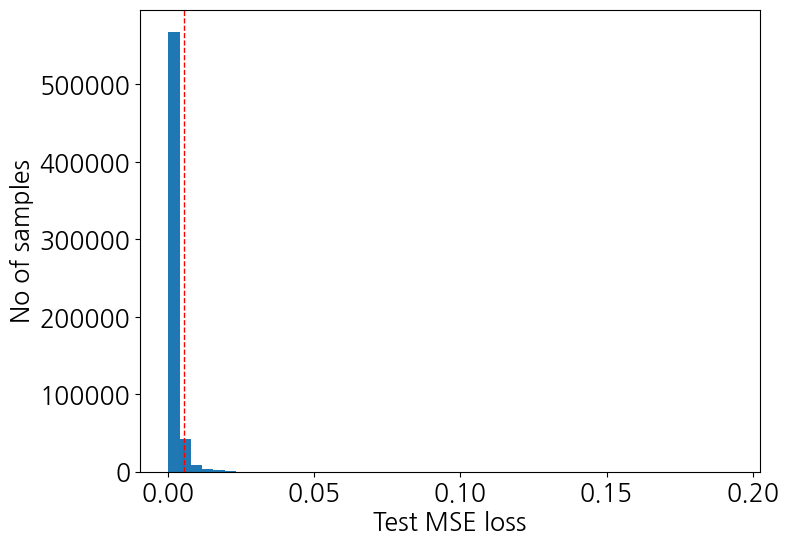

 test 데이터의 불량예측 개수:  0.0


In [32]:
# 시각화
plt.figure(figsize=(8,6))
plt.hist(ae_test, bins=50)
plt.xlabel("Test MSE loss")
plt.ylabel("No of samples")
plt.axvline(best_threshold, color='red', linestyle='--', linewidth=1)
plt.show()
# test 데이터의 불량 갯수(임계치 기준)
test_Y_normal = ae_test >best_threshold
print(" test 데이터의 불량예측 개수: ", np.median(test_Y_normal))

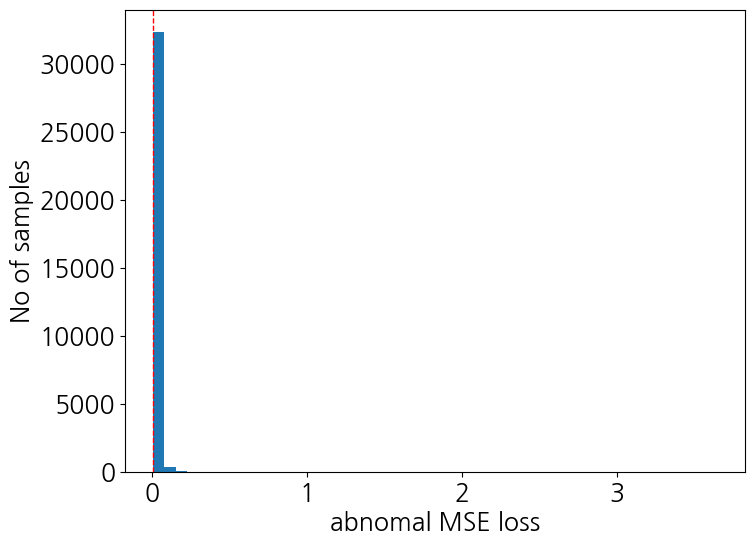

이상점으로 예측한 개수:  32582


In [33]:
# 모두 비정상인 값 예측
# 시각화
plt.figure(figsize=(8,6))
plt.hist(ae_abnormal, bins=50)
plt.xlabel("abnomal MSE loss")
plt.ylabel("No of samples")
plt.axvline(best_threshold, color='red', linestyle='--', linewidth=1)
plt.show()
# 이상점으로 판단한 데이터 확인
test_N_abnormal = ae_abnormal > best_threshold
print("이상점으로 예측한 개수: ", np.sum(test_N_abnormal))

In [34]:
from sklearn.metrics import confusion_matrix
# 결과 값을 통한 정량적 지표 확인
# 실제 양품 불량으로 결합
true = np.concatenate([np.zeros(len(y_normal_test)), np.ones(len(abnormal_data))])
# 예측한 양품, 불량으로 결합
prediction = np.concatenate([test_Y_normal, test_N_abnormal])
aepredict = prediction
# 혼동 행렬
confusion_matrix(true, prediction)

array([[583378,  43215],
       [    93,  32582]])

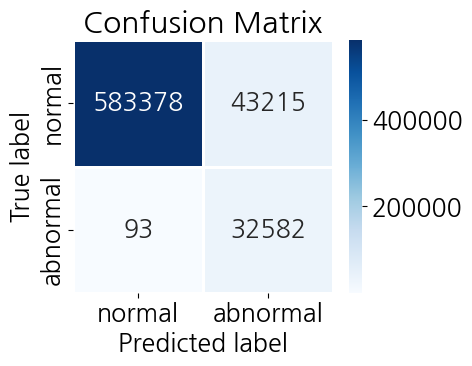

In [35]:
cm = confusion_matrix(true, prediction)
class_names=['normal', 'abnormal']
fig = plt.figure(figsize=(5,4))
ax = sns.heatmap(cm, annot=True, cmap='Blues', linewidths=1, fmt="d",
 xticklabels=['normal', 'abnormal'], yticklabels=['normal', 'abnormal'])
ax.set(title='Confusion Matrix',
 ylabel='True label',
 xlabel='Predicted label')
plt.tight_layout()
plt.savefig('AE_53_1.png')


In [36]:
from sklearn.metrics import classification_report
print(classification_report(true, prediction, target_names=['normal', 'abnormal']))

              precision    recall  f1-score   support

      normal       1.00      0.93      0.96    626593
    abnormal       0.43      1.00      0.60     32675

    accuracy                           0.93    659268
   macro avg       0.71      0.96      0.78    659268
weighted avg       0.97      0.93      0.95    659268



## memAE

### Model Define 

In [37]:
from memory_module import MemModule

class MEMAE(nn.Module):
    def __init__(self):
        super(MEMAE, self).__init__()
        self.channel_num_in = 8

        self.encoder = nn.Sequential(
            nn.Linear(self.channel_num_in, 8),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.BatchNorm1d(4),
            nn.ReLU(),
            nn.Linear(4, 2),
            nn.BatchNorm1d(2),
            nn.ReLU()
        )

        mem_dim = 350

        self.mem_rep = MemModule(mem_dim=mem_dim, fea_dim=2)

        self.decoder = nn.Sequential(
            nn.Linear(2, 4),
            nn.BatchNorm1d(4),
            nn.ReLU(),
            nn.Linear(4, 8),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Linear(8, self.channel_num_in),
            nn.BatchNorm1d(self.channel_num_in),
            nn.ReLU()
        )

    def forward(self, x):
        f = self.encoder(x)
        res_mem = self.mem_rep(f)
        f = res_mem['output']
        att = res_mem['att']
        output = self.decoder(f)
        return {'output': output, 'att': att}

    def compute_loss(self, outputs, target):
        output = outputs['output']
        att = outputs['att']
        # loss = reconsturction loss + entropy of w
        recon_loss = torch.nn.MSELoss()(output, target)
        entropy_loss = torch.mean((-att) * torch.log(att + 1e-12))
        loss = recon_loss + 0.0002*entropy_loss

        return loss

    def compute_batch_error(self, outputs, target):
        output = outputs['output']
        loss = torch.nn.MSELoss(reduction='none')(output, target)
        batch_error = loss.mean(1)
        return batch_error


if __name__ == "__main__":
    model = MEMAE()
    print(model)

MEMAE(
  (encoder): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=8, out_features=4, bias=True)
    (4): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=4, out_features=2, bias=True)
    (7): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
  )
  (mem_rep): MemModule(
    (memory): MemoryUnit(mem_dim=350, fea_dim=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=4, out_features=8, bias=True)
    (4): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=8, bi

### Model Train

In [38]:

model = MEMAE().to(DEVICE)

model.train(True)
best_model = None
best_loss = float('inf')
increasing_loss_count = 0

train_losses = []
val_losses = []

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_idx, (data, targets) in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        data = data.to(DEVICE)
        targets = targets.to(DEVICE)
        outputs = model(data)
        loss = model.compute_loss(outputs, targets)
        
        # backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data, targets in train_val_dataloader:
            data = data.to(DEVICE)
            targets = targets.to(DEVICE)
            outputs = model(data)
            loss = model.compute_loss(outputs, targets)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(train_val_dataloader)
    val_losses.append(avg_val_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")
    
    # Check if validation loss has increased
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        best_model = model
        increasing_loss_count = 0
    else:
        increasing_loss_count += 1

    # Early stopping condition
    if increasing_loss_count >= 5:
        print("Early stopping due to increase in validation loss for 10 consecutive epochs.")
        break

    model.train(True)

# Return the best model
torch.save(best_model.state_dict(), 'mAE_53_1.pth')

Epoch 1/100: 100%|███████████████████████| 31330/31330 [01:26<00:00, 362.70it/s]


Epoch [1/100], Train Loss: 0.047276, Val Loss: 0.031310


Epoch 2/100: 100%|███████████████████████| 31330/31330 [01:26<00:00, 363.22it/s]


Epoch [2/100], Train Loss: 0.020762, Val Loss: 0.014948


Epoch 3/100: 100%|███████████████████████| 31330/31330 [01:26<00:00, 363.34it/s]


...

Epoch [25/100], Train Loss: 0.001981, Val Loss: 0.001320


Epoch 26/100: 100%|██████████████████████| 31330/31330 [01:26<00:00, 363.73it/s]


Epoch [26/100], Train Loss: 0.001987, Val Loss: 0.001358


Epoch 27/100: 100%|██████████████████████| 31330/31330 [01:26<00:00, 363.61it/s]


Epoch [27/100], Train Loss: 0.001969, Val Loss: 0.001358
Early stopping due to increase in validation loss for 10 consecutive epochs.


### model inference

In [39]:
MAEmodel = MEMAE().to(DEVICE)  # 여기서 YourModelClass는 모델의 클래스 이름입니다.
MAEmodel.load_state_dict(torch.load('mAE_53_1.pth'))
MAEmodel.to(DEVICE)  # 모델을 원하는 디바이스로 이동

MEMAE(
  (encoder): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=8, out_features=4, bias=True)
    (4): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=4, out_features=2, bias=True)
    (7): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
  )
  (mem_rep): MemModule(
    (memory): MemoryUnit(mem_dim=350, fea_dim=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=4, out_features=8, bias=True)
    (4): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=8, bi

In [40]:
def score(model, dataloader):
    model.eval()  # 모델을 평가 모드로 설정
    total_scores = []
    
    with torch.no_grad():
        for data, _ in dataloader:  # 라벨이 없다고 가정
            data = data.to(DEVICE)
            outputs = model(data)
            
            # 복원 오차 계산
            reconstruction_error = (data - outputs['output']).pow(2).mean(dim=1).cpu().numpy()
            total_scores.extend(reconstruction_error)
            #append = np.append(append, outputs['output'].cpu().numpy())
    
    return np.array(total_scores), pd.DataFrame(data.cpu().numpy()), pd.DataFrame(outputs['output'].cpu().numpy())

In [41]:
X_normal_train_dataset = CustomDataset(X_normal_train)
X_normal_dataset = CustomDataset(X_normal_test)
X_normal_train_loader = DataLoader(X_normal_train_dataset, batch_size=64, shuffle=False)
X_normal_test_loader = DataLoader(X_normal_dataset, batch_size=64)

abnormal_df =abnormal_data.copy()
# 불필요한 변수 삭제
abnormal_df = abnormal_df.drop(['설비 이상신호'], axis=1)
abnomal_dataset = CustomDataset(abnormal_df)
abnomal_dataloader = DataLoader(abnomal_dataset, batch_size=64)

In [42]:
mae_train, mae_train_in, mae_train_out = score(MAEmodel, X_normal_train_loader)
mae_test, mae_test_in, mae_test_out= score(MAEmodel, X_normal_test_loader)
mae_abnormal, mae_an_in, mae_ab_out  = score(MAEmodel, abnomal_dataloader)

57501.3125


In [43]:
true = np.concatenate([np.zeros(len(y_normal_train)), np.zeros(len(y_normal_test)), np.ones(len(abnormal_data))])
mae_scores = np.hstack([mae_train, mae_test, mae_abnormal])

fpr,tpr, threshold= roc_curve(true,mae_scores,pos_label=1)
distance = np.sqrt((1-tpr)**2+fpr**2)

best_threshold = threshold[np.argmin(distance)]

Text(0.5, 1.0, 'Test Data')

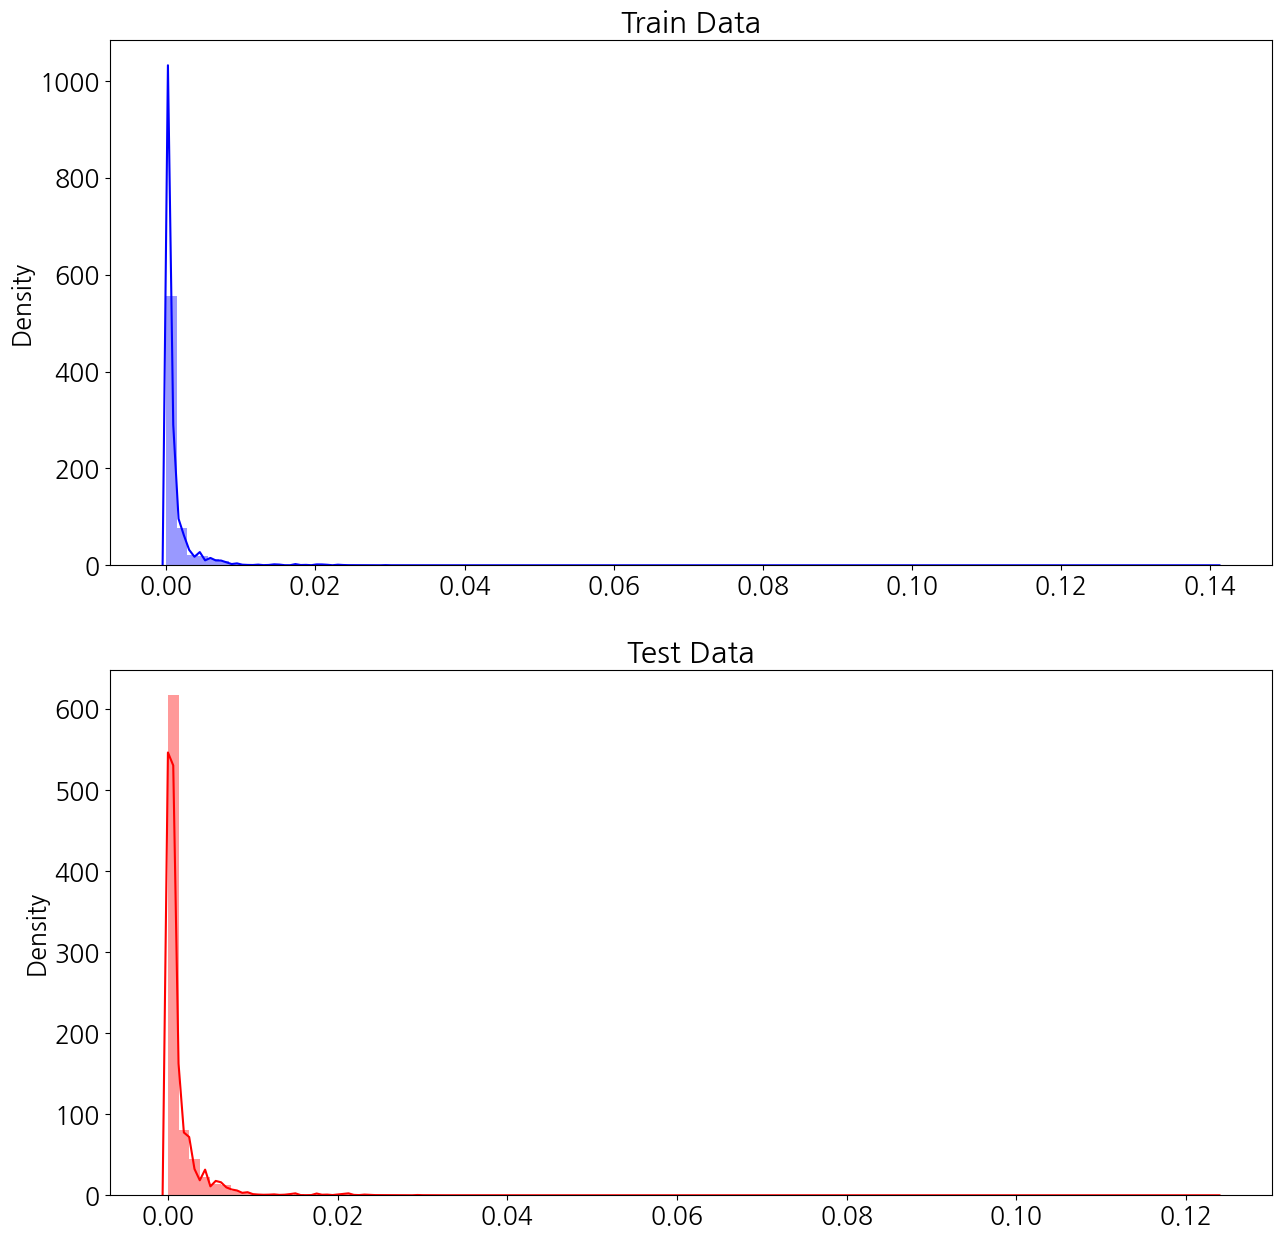

In [44]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize = (15, 15))
sns.distplot(mae_train, bins=100, kde=True, color='blue', ax=ax1)
sns.distplot(mae_test, bins=100, kde=True, color='red', ax=ax2)
ax1.set_title("Train Data")
ax2.set_title("Test Data")

In [45]:
# 임계값은 0.03로 함
mmerged_data = pd.concat([X_normal_train, X_normal_test])
mae_scores = pd.DataFrame(index=mmerged_data.index)
mae_scores['score'] = list(np.hstack([mae_train, mae_test]))

mae_scores['anomaly'] = best_threshold < mae_scores['score']
mae_scores.head()

,score,anomaly
86406,0.000359,False
795114,0.000178,False
2054155,0.000823,False
505068,0.000178,False
2794175,0.000849,False


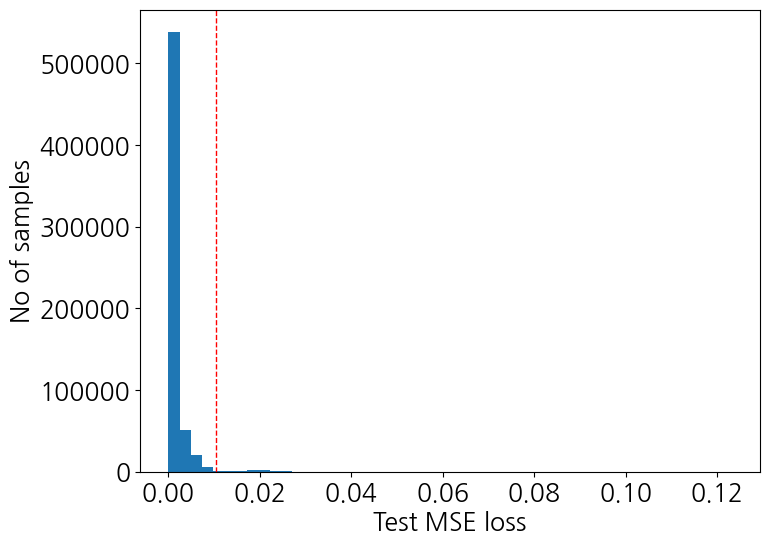

 test 데이터의 불량예측 개수:  9160


In [46]:
# 시각화
plt.figure(figsize=(8,6))
plt.hist(mae_test, bins=50)
plt.xlabel("Test MSE loss")
plt.ylabel("No of samples")
plt.axvline(best_threshold, color='red', linestyle='--', linewidth=1)
plt.show()
# test 데이터의 불량 갯수(임계치 기준)
test_Y_normal = mae_test > best_threshold
print(" test 데이터의 불량예측 개수: ", np.sum(test_Y_normal))

In [47]:
abnormal_df =abnormal_data.copy()
# 불필요한 변수 삭제
abnormal_df = abnormal_df.drop(['설비 이상신호'], axis=1)
abnomal_dataset = CustomDataset(abnormal_df)
abnomal_dataloader = DataLoader(abnomal_dataset, batch_size=64)
# 모두 비정상 값 복원오차 값 도출
mae_abnormal, data, mae_abnomal_out= score(MAEmodel, abnomal_dataloader)

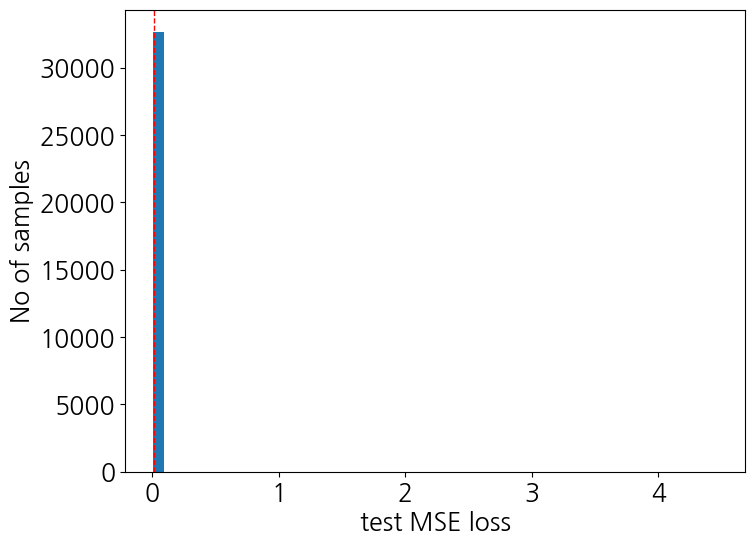

이상점으로 예측한 개수:  32653


In [48]:
# 모두 비정상인 값 예측
# 시각화
plt.figure(figsize=(8,6))
plt.hist(mae_abnormal, bins=50)
plt.xlabel("test MSE loss")
plt.ylabel("No of samples")
plt.axvline(best_threshold, color='red', linestyle='--', linewidth=1)
plt.show()
# 이상점으로 판단한 데이터 확인
test_N_abnormal = mae_abnormal >best_threshold
print("이상점으로 예측한 개수: ", np.sum(test_N_abnormal))

In [49]:
from sklearn.metrics import confusion_matrix
# 결과 값을 통한 정량적 지표 확인
# 실제 양품 불량으로 결합
true = np.concatenate([np.zeros(len(y_normal_test)), np.ones(len(abnormal_data))])
# 예측한 양품, 불량으로 결합
prediction = np.concatenate([test_Y_normal, test_N_abnormal])
maepredict = prediction
# 혼동 행렬
confusion_matrix(true, prediction)

array([[617433,   9160],
       [    22,  32653]])

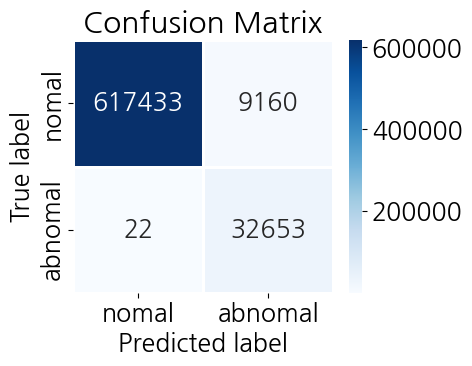

In [50]:
cm = confusion_matrix(true, prediction)
class_names=['nomal','abnomal']
fig = plt.figure(figsize=(5,4))
ax = sns.heatmap(cm, annot=True, cmap='Blues', linewidths=1, fmt="d",
 xticklabels=['nomal','abnomal'], yticklabels=['nomal','abnomal'])
ax.set(title='Confusion Matrix',
 ylabel='True label',
 xlabel='Predicted label')
plt.tight_layout()
plt.savefig('memAE_52_1.png')

In [74]:
true_df = pd.DataFrame(true)
true_df.to_csv("memTrue.csv", mode='w')

true_df = pd.DataFrame(true.astype(int))
true_df.to_csv("memTrue.csv", mode='w')

In [67]:
prediction_df = pd.DataFrame(prediction)
prediction_df.to_csv("memprediction.csv", mode='w')

In [66]:
from sklearn.metrics import classification_report
print(classification_report(true, prediction, target_names=['normal', 'abnormal']))

              precision    recall  f1-score   support

      normal       1.00      0.99      0.99    626593
    abnormal       0.78      1.00      0.88     32675

    accuracy                           0.99    659268
   macro avg       0.89      0.99      0.93    659268
weighted avg       0.99      0.99      0.99    659268



## Usad

### model define

In [ ]:
class Encoder(nn.Module):
  def __init__(self, in_size):
    super().__init__()
    self.linear1 = nn.Linear(in_size, 8)    
    self.linear2 = nn.Linear(8, 4)
    self.linear3 = nn.Linear(4, 2)
    self.BN1= nn.BatchNorm1d(8)
    self.BN2= nn.BatchNorm1d(4)
    self.BN3= nn.BatchNorm1d(2)
    self.relu = nn.ReLU(True)

  def forward(self, w):
    out = self.linear1(w)
    out = self.BN1(out)
    out = self.relu(out)
    out = self.linear2(out)
    out = self.BN2(out)
    out = self.relu(out)
    out = self.linear3(out)
    out = self.BN3(out)
    z = self.relu(out)
    return z

class Decoder(nn.Module):
  def __init__(self, out_size):
    super().__init__()
    self.linear1 = nn.Linear(2, 4)
    self.linear2 = nn.Linear(4, 8)
    self.linear3 = nn.Linear(8, out_size)
    self.relu = nn.ReLU(True)
    self.BN1= nn.BatchNorm1d(4)
    self.BN2= nn.BatchNorm1d(8)
    self.BN3= nn.BatchNorm1d(out_size)
    self.sigmoid = nn.Sigmoid()

  def forward(self, z):
    out = self.linear1(z)
    out = self.BN1(out)
    out = self.relu(out)
    out = self.linear2(out)
    out = self.BN2(out)
    out = self.relu(out)
    out = self.linear3(out)
    out = self.BN3(out)  
    w = self.relu(out)
    return w
    
class UsadModel(nn.Module):
  def __init__(self, w_size):
    super().__init__()
    self.encoder = Encoder(w_size)
    self.decoder1 = Decoder(w_size)
    self.decoder2 = Decoder(w_size)
  
  def training_step(self, batch, n):
    z = self.encoder(batch)
    w1 = self.decoder1(z)
    w2 = self.decoder2(z)
    w3 = self.decoder2(self.encoder(w1))
    loss1 = 1/n*torch.mean((batch-w1)**2)+(1-1/n)*torch.mean((batch-w3)**2)
    loss2 = 1/n*torch.mean((batch-w2)**2)-(1-1/n)*torch.mean((batch-w3)**2)
    return loss1,loss2

  def validation_step(self, batch, n):
    with torch.no_grad():
        z = self.encoder(batch)
        w1 = self.decoder1(z)
        w2 = self.decoder2(z)
        w3 = self.decoder2(self.encoder(w1))
        loss1 = 1/n*torch.mean((batch-w1)**2)+(1-1/n)*torch.mean((batch-w3)**2)
        loss2 = 1/n*torch.mean((batch-w2)**2)-(1-1/n)*torch.mean((batch-w3)**2)
    return {'val_loss1': loss1, 'val_loss2': loss2}
        
  def validation_epoch_end(self, outputs):
    batch_losses1 = [x['val_loss1'] for x in outputs]
    epoch_loss1 = torch.stack(batch_losses1).mean()
    batch_losses2 = [x['val_loss2'] for x in outputs]
    epoch_loss2 = torch.stack(batch_losses2).mean()
    return {'val_loss1': epoch_loss1.item(), 'val_loss2': epoch_loss2.item()}
    
  def epoch_end(self, epoch, result):
    print("Epoch [{}], val_loss1: {:.6f}, val_loss2: {:.6f}".format(epoch, result['val_loss1'], result['val_loss2']))

### model Train

In [ ]:
model = UsadModel(8).to(DEVICE)
model.train(True)
best_model = None
best_loss = float('inf')
increasing_loss_count = 0
num_epochs = 100
train_losses = []
val_losses = []
opt_func=torch.optim.Adam
optimizer1 = opt_func(list(model.encoder.parameters())+list(model.decoder1.parameters()),lr=0.0001)
optimizer2 = opt_func(list(model.encoder.parameters())+list(model.decoder2.parameters()),lr=0.0001)
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_idx, (data, targets) in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        data = data.to(DEVICE)
        targets = targets.to(DEVICE)
        loss1,loss2 = model.training_step(data,epoch+1)
        loss1.backward()
        optimizer1.step()
        optimizer1.zero_grad()

        loss1,loss2 = model.training_step(data,epoch+1)
        loss2.backward()
        optimizer2.step()
        optimizer2.zero_grad()
    
    model.eval()
    with torch.no_grad():
        outputs = []
        for data, targets in train_val_dataloader:
            data = data.to(DEVICE)
            targets = targets.to(DEVICE)
            output = model.validation_step(data, epoch+1)
            outputs.append(output)
        result = model.validation_epoch_end(outputs)
            #val_losses.append(output)
        
        model.epoch_end(epoch, result)
    
    if result['val_loss2'] < best_loss:
        best_loss = result['val_loss2']
        best_model = model
        increasing_loss_count = 0
    else:
        increasing_loss_count += 1

    # Early stopping condition
    if increasing_loss_count >= 5:
        print("Early stopping due to increase in validation loss for 10 consecutive epochs.")
        break

    model.train(True)
        
torch.save(best_model.state_dict(), 'usad_IQR_Z_all99.pth')   

### inference

In [ ]:
USADmodel = UsadModel(8).to(DEVICE)  # 여기서 YourModelClass는 모델의 클래스 이름입니다.
USADmodel.load_state_dict(torch.load('usad_IQR_Z_all99.pth'))
USADmodel.to(DEVICE)  # 모델을 원하는 디바이스로 이동

In [ ]:
X_normal_train_dataset = CustomDataset(X_normal_train)
X_normal_dataset = CustomDataset(X_normal_test)
X_normal_train_loader = DataLoader(X_normal_train_dataset, batch_size=64, shuffle=False)
X_normal_test_loader = DataLoader(X_normal_dataset, batch_size=64)

abnormal_df =abnormal_data.copy()
# 불필요한 변수 삭제
abnormal_df = abnormal_df.drop(['설비 이상신호'], axis=1)
abnomal_dataset = CustomDataset(abnormal_df)
abnomal_dataloader = DataLoader(abnomal_dataset, batch_size=64)

In [ ]:
def testing(model, test_loader, alpha=.9, beta=.1):
    results=[]
    with torch.no_grad():
        for data, targets in test_loader:
            data = data.to(DEVICE)
            w1=model.decoder1(model.encoder(data))
            w2=model.decoder2(model.encoder(w1))
            reconstruction_error = alpha*torch.mean((data-w1)**2,axis=1)+beta*torch.mean((data-w2)**2,axis=1)
            results.extend(reconstruction_error.cpu().numpy())
    return results

In [ ]:
starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)   # Time evaluation 
starter.record()

usad_train = testing(USADmodel, X_normal_train_loader)
usad_test= testing(USADmodel, X_normal_test_loader)
usad_abnormal = testing(USADmodel, abnomal_dataloader)

ender.record()
torch.cuda.synchronize()
curr_time = starter.elapsed_time(ender)
print(curr_time)

In [ ]:

true = np.concatenate([np.zeros(len(y_normal_train)), np.zeros(len(y_normal_test)), np.ones(len(abnormal_data))])
usad_scores = np.hstack([usad_train, usad_test,usad_abnormal])

fpr,tpr, threshold= roc_curve(true,usad_scores,pos_label=1)
distance = np.sqrt((1-tpr)**2+fpr**2)

best_threshold = threshold[np.argmin(distance)]

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize = (15, 15))
sns.distplot(usad_train, bins=100, kde=True, color='blue', ax=ax1)
sns.distplot(usad_test, bins=100, kde=True, color='red', ax=ax2)
ax1.set_title("Train Data")
ax2.set_title("Test Data")

In [ ]:
# 임계값은 0.03로 함
mmerged_data = pd.concat([X_normal_train, X_normal_test])
usad_scores = pd.DataFrame(index=mmerged_data.index)
usad_scores['score'] = list(np.hstack([usad_train, usad_test]))

usad_scores['anomaly'] = best_threshold < usad_scores['score']
usad_scores.head()

In [ ]:
# 시각화
plt.figure(figsize=(8,6))
plt.hist(usad_test, bins=50)
plt.xlabel("Test MSE loss")
plt.ylabel("No of samples")
plt.axvline(best_threshold, color='red', linestyle='--', linewidth=1)
plt.show()
# test 데이터의 불량 갯수(임계치 기준)
test_Y_normal = [x > best_threshold for x in usad_test]
print(" test 데이터의 불량예측 개수: ", np.sum(test_Y_normal))

In [ ]:
abnormal_df =abnormal_data.copy()
# 불필요한 변수 삭제
abnormal_df = abnormal_df.drop(['설비 이상신호'], axis=1)
abnomal_dataset = CustomDataset(abnormal_df)
abnomal_dataloader = DataLoader(abnomal_dataset, batch_size=64)
# 모두 비정상 값 복원오차 값 도출
usad_abnormal = testing(USADmodel, abnomal_dataloader)

In [ ]:
# 모두 비정상인 값 예측
# 시각화
plt.figure(figsize=(8,6))
plt.hist(usad_abnormal, bins=50)
plt.xlabel("test MSE loss")
plt.ylabel("No of samples")
plt.axvline(best_threshold, color='red', linestyle='--', linewidth=1)
plt.show()
# 이상점으로 판단한 데이터 확인
test_N_abnormal = [x > best_threshold for x in usad_abnormal]
print("이상점으로 예측한 개수: ", np.sum(test_N_abnormal))

In [ ]:
from sklearn.metrics import confusion_matrix
# 결과 값을 통한 정량적 지표 확인
# 실제 양품 불량으로 결합
true = np.concatenate([np.zeros(len(y_normal_test)), np.ones(len(abnormal_data))])
# 예측한 양품, 불량으로 결합
prediction = np.concatenate([test_Y_normal, test_N_abnormal])
usadpredict= prediction
# 혼동 행렬
confusion_matrix(true, prediction)

In [ ]:
cm = confusion_matrix(true, prediction)
class_names=['normal', 'abnormal']
fig = plt.figure(figsize=(5,4))
ax = sns.heatmap(cm, annot=True, cmap='Blues', linewidths=1, fmt="d",
 xticklabels=['normal', 'abnormal'], yticklabels=['normal', 'abnormal'])
ax.set(title='Confusion Matrix',
 ylabel='True label',
 xlabel='Predicted label')
plt.tight_layout()
plt.savefig('USAD_99.png')

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(true, prediction, target_names=['normal', 'abnormal']))

## mem+usad

### model Define

In [147]:
from memory_module import MemModule

class Encoder(nn.Module):
  def __init__(self, in_size):
    super().__init__()
    self.linear1 = nn.Linear(in_size, 8)    
    self.linear2 = nn.Linear(8, 4)
    self.linear3 = nn.Linear(4, 2)
    self.BN1= nn.BatchNorm1d(8)
    self.BN2= nn.BatchNorm1d(4)
    self.BN3= nn.BatchNorm1d(2)
    self.relu = nn.ReLU(True)

  def forward(self, w):
    out = self.linear1(w)
    out = self.BN1(out)
    out = self.relu(out)
    out = self.linear2(out)
    out = self.BN2(out)
    out = self.relu(out)
    out = self.linear3(out)
    out = self.BN3(out)
    z = self.relu(out)
    return z

class Decoder(nn.Module):
  def __init__(self, out_size):
    super().__init__()
    self.linear1 = nn.Linear(2, 4)
    self.linear2 = nn.Linear(4, 8)
    self.linear3 = nn.Linear(8, out_size)
    self.relu = nn.ReLU(True)
    self.BN1= nn.BatchNorm1d(4)
    self.BN2= nn.BatchNorm1d(8)
    self.BN3= nn.BatchNorm1d(out_size)
    self.sigmoid = nn.Sigmoid()

  def forward(self, z):
    out = self.linear1(z)
    out = self.BN1(out)
    out = self.relu(out)
    out = self.linear2(out)
    out = self.BN2(out)
    out = self.relu(out)
    out = self.linear3(out)
    out = self.BN3(out)  
    w = self.relu(out)
    return w

class MUsadModel(nn.Module):
  def __init__(self, w_size):
    super().__init__()
    self.encoder = Encoder(w_size)
    self.mem_rep = MemModule(mem_dim=30, fea_dim=2)
    self.decoder1 = Decoder(w_size)
    self.decoder2 = Decoder(w_size)

  def training_step(self, batch, n):
    z = self.encoder(batch)
    res_mem = self.mem_rep(z)
    z = res_mem['output']
    att = res_mem['att']
    w1 = self.decoder1(z)
    w2 = self.decoder2(z)
    w3 = self.decoder2(self.encoder(w1))

    recon_loss1 = torch.nn.MSELoss()(w1, batch)
    recon_loss2 = torch.nn.MSELoss()(w2, batch)
    recon_loss3 = torch.nn.MSELoss()(w3, batch)
    entropy_loss = torch.mean((-att) * torch.log(att + 1e-12))

    memloss1 = recon_loss1 + 0.0002*entropy_loss
    memloss2 = recon_loss2 + 0.0002*entropy_loss
    memloss3 = recon_loss3 + 0.0002*entropy_loss

    loss1 = 1/n*memloss1+(1-1/n)*memloss3
    loss2 = 1/n*memloss2-(1-1/n)*memloss3
    return loss1,loss2

  def validation_step(self, batch, n):
    with torch.no_grad():
        z = self.encoder(batch)
        res_mem = self.mem_rep(z)
        z = res_mem['output']
        att = res_mem['att']
        w1 = self.decoder1(z)
        w2 = self.decoder2(z)
        w3 = self.decoder2(self.encoder(w1))

        recon_loss1 = torch.nn.MSELoss()(w1, batch)
        recon_loss2 = torch.nn.MSELoss()(w2, batch)
        recon_loss3 = torch.nn.MSELoss()(w3, batch)
        entropy_loss = torch.mean((-att) * torch.log(att + 1e-12))

        memloss1 = recon_loss1 + 0.0002*entropy_loss
        memloss2 = recon_loss2 + 0.0002*entropy_loss
        memloss3 = recon_loss3 + 0.0002*entropy_loss

        
        loss1 = 1/n*memloss1+(1-1/n)*memloss3
        loss2 = 1/n*memloss2-(1-1/n)*memloss3
    return {'val_loss1': loss1, 'val_loss2': loss2}

  def validation_epoch_end(self, outputs):
    batch_losses1 = [x['val_loss1'] for x in outputs]
    epoch_loss1 = torch.stack(batch_losses1).mean()
    batch_losses2 = [x['val_loss2'] for x in outputs]
    epoch_loss2 = torch.stack(batch_losses2).mean()
    return {'val_loss1': epoch_loss1.item(), 'val_loss2': epoch_loss2.item()}

  def epoch_end(self, epoch, result):
    print("Epoch [{}], val_loss1: {:.4f}, val_loss2: {:.4f}".format(epoch, result['val_loss1'], result['val_loss2']))

### model Train

In [148]:

model = MUsadModel(8).to(DEVICE)

model.train(True)
best_model = None
best_loss = float('inf')
increasing_loss_count = 0
num_epochs = 100
train_losses = []
val_losses = []
opt_func=torch.optim.Adam
optimizer1 = opt_func(list(model.encoder.parameters())+list(model.decoder1.parameters()),lr=0.0001)
optimizer2 = opt_func(list(model.encoder.parameters())+list(model.decoder2.parameters()),lr=0.0001)
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_idx, (data, targets) in enumerate(tqdm(train_dataloader, desc=f"train Epoch {epoch+1}/{num_epochs}")):
        data = data.to(DEVICE)
        targets = targets.to(DEVICE)
        loss1,loss2 = model.training_step(data,epoch+1)
        loss1.backward()
        optimizer1.step()
        optimizer1.zero_grad()

        loss1,loss2 = model.training_step(data,epoch+1)
        loss2.backward()
        optimizer2.step()
        optimizer2.zero_grad()
    
    model.eval()
    with torch.no_grad():
        outputs = []
        for batch_idx, (data, targets) in enumerate(tqdm(train_val_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")):
            data = data.to(DEVICE)
            targets = targets.to(DEVICE)
            output = model.validation_step(data, epoch+1)
            outputs.append(output)
        result = model.validation_epoch_end(outputs)
            #val_losses.append(output)
        
        model.epoch_end(epoch, result)
    
    if result['val_loss2'] < best_loss:
        best_loss = result['val_loss2']
        best_model = model
        increasing_loss_count = 0
    else:
        increasing_loss_count += 1

    # Early stopping condition
    if increasing_loss_count >= 10: 
        print("Early stopping due to increase in validation loss for 10 consecutive epochs.")
        break

    model.train(True)
        
torch.save(best_model.state_dict(), 'Musad_53.pth')   

Epoch 1/100: 100%|█████████████████████████| 3917/3917 [00:22<00:00, 173.83it/s]


Epoch [0], val_loss1: 0.0902, val_loss2: 0.0969


Epoch 2/100: 100%|█████████████████████████| 3917/3917 [00:22<00:00, 173.87it/s]


Epoch [1], val_loss1: 0.2993, val_loss2: -0.2014


Epoch 3/100: 100%|█████████████████████████| 3917/3917 [00:22<00:00, 173.94it/s]


...

Epoch 7/100: 100%|█████████████████████████| 3917/3917 [00:22<00:00, 174.26it/s]


Epoch [6], val_loss1: 0.1535, val_loss2: -0.1373


Epoch 8/100: 100%|█████████████████████████| 3917/3917 [00:22<00:00, 174.30it/s]


Epoch [7], val_loss1: 0.0670, val_loss2: -0.0537


Epoch 9/100:  68%|████████████████▉        | 2658/3917 [00:15<00:07, 177.70it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



### model infer

In [149]:
MUSADmodel = MUsadModel(8).to(DEVICE)
MUSADmodel.load_state_dict(torch.load('Musad_53.pth'))
MUSADmodel.to(DEVICE)

MUsadModel(
  (encoder): Encoder(
    (linear1): Linear(in_features=8, out_features=8, bias=True)
    (linear2): Linear(in_features=8, out_features=4, bias=True)
    (linear3): Linear(in_features=4, out_features=2, bias=True)
    (BN1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (BN2): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (BN3): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
  )
  (mem_rep): MemModule(
    (memory): MemoryUnit(mem_dim=30, fea_dim=True)
  )
  (decoder1): Decoder(
    (linear1): Linear(in_features=2, out_features=4, bias=True)
    (linear2): Linear(in_features=4, out_features=8, bias=True)
    (linear3): Linear(in_features=8, out_features=8, bias=True)
    (relu): ReLU(inplace=True)
    (BN1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (BN2): BatchNorm1d(8, eps=1e-05, momentum=0.1, aff

In [150]:
def testing(model, test_loader, alpha=.9, beta=.1):
    results=[]
    with torch.no_grad():
        for data, targets in test_loader:
            data = data.to(DEVICE)
            z1 = model.encoder(data)
            res_mem = model.mem_rep(z1)
            z1 = res_mem['output']
            att = res_mem['att']
            w1 = model.decoder1(z1)
            z2 = model.encoder(data)
            res_mem = model.mem_rep(z2)
            z2 = res_mem['output']
            w2 = model.decoder2(z2)
            reconstruction_error = alpha*torch.mean((data-w1)**2,axis=1)+beta*torch.mean((data-w2)**2,axis=1)
            w1_c = w1.cpu().numpy()
            w2_c = w2.cpu().numpy()
            out = (alpha* w1_c) + (beta*w2_c)
            results.extend(reconstruction_error.cpu().numpy())
    return results, data.cpu().numpy(), out

In [151]:
musad_train, musad_train_in, musad_train_out  = testing(MUSADmodel, X_normal_train_loader)
musad_test, musad_test_in,musad_test_out= testing(MUSADmodel, X_normal_test_loader)
musad_abnormal, musad_abnomal_in,musad_abnormal_out = testing(MUSADmodel, abnomal_dataloader)

In [152]:
true = np.concatenate([np.zeros(len(y_normal_train)), np.zeros(len(y_normal_test)), np.ones(len(abnormal_data))])
musad_scores = np.hstack([musad_train, musad_test,musad_abnormal])

fpr,tpr, threshold= roc_curve(true,musad_scores,pos_label=1)
distance = np.sqrt((1-tpr)**2+fpr**2)

best_threshold = threshold[np.argmin(distance)]

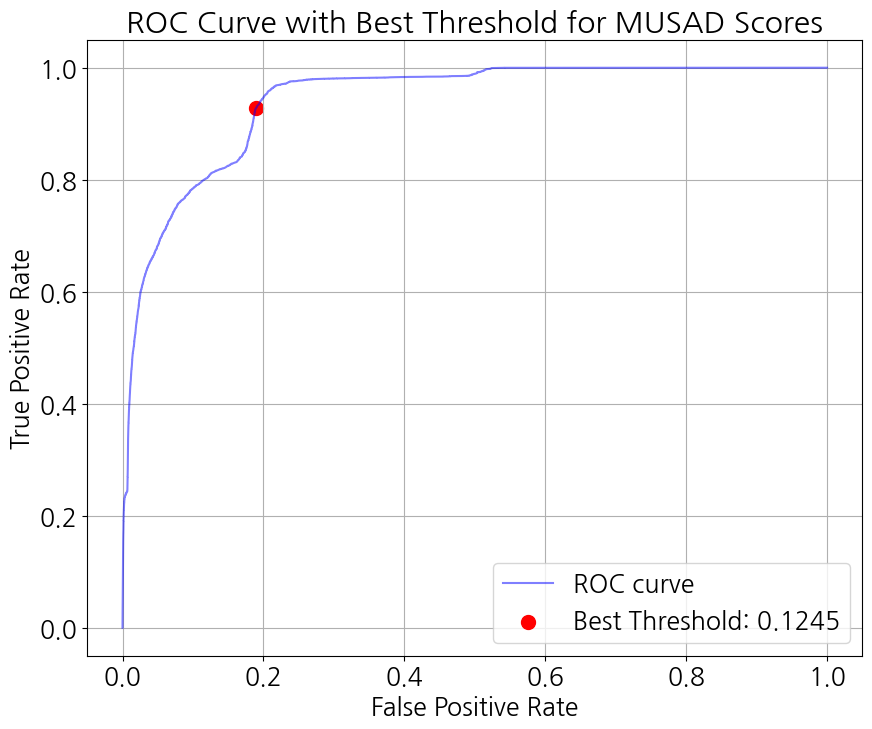

In [153]:
# Plotting
plt.figure(figsize=(10, 8))

# ROC curve
plt.plot(fpr, tpr, label='ROC curve', color='blue', alpha=0.5)
plt.title('ROC Curve with Best Threshold for MUSAD Scores')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
best_threshold_index = np.argmin(distance)
# Best threshold point
plt.scatter(fpr[best_threshold_index], tpr[best_threshold_index], color='red', s=100, label=f'Best Threshold: {threshold[best_threshold_index]:.4f}')

plt.legend()
plt.grid(True)
plt.show()


Text(0.5, 1.0, 'Test Data')

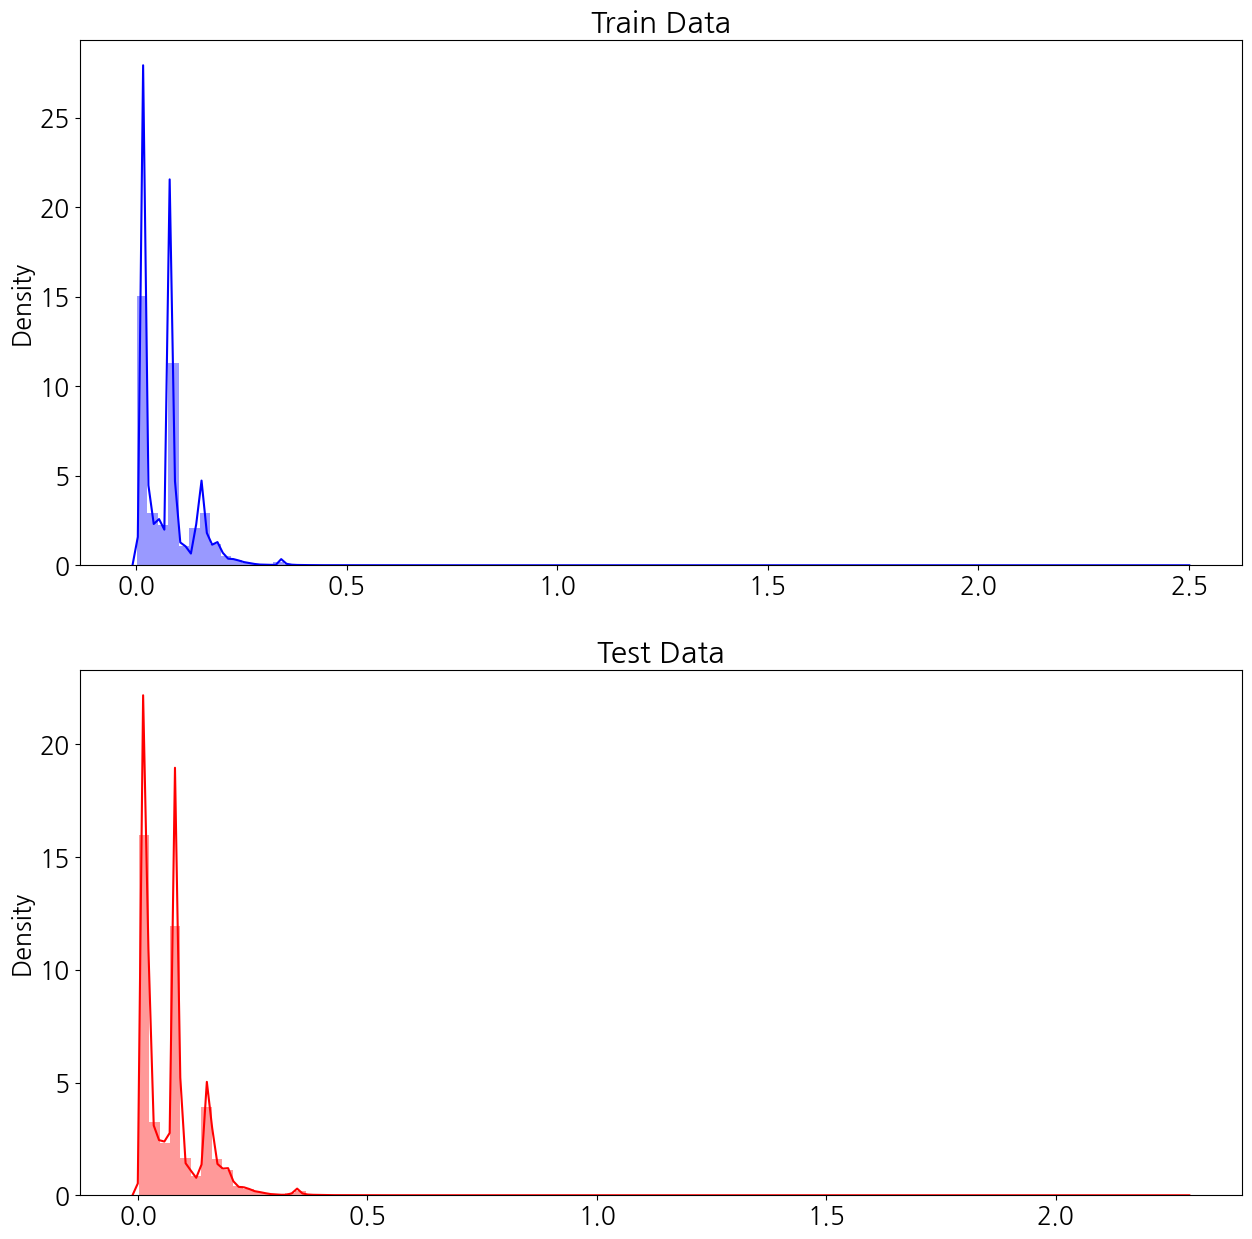

In [154]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize = (15, 15))
sns.distplot(musad_train, bins=100, kde=True, color='blue', ax=ax1)
sns.distplot(musad_test, bins=100, kde=True, color='red', ax=ax2)
ax1.set_title("Train Data")
ax2.set_title("Test Data")

In [155]:
# 임계값은 0.03로 함
mmerged_data = pd.concat([X_normal_train, X_normal_test])
musad_scores = pd.DataFrame(index=mmerged_data.index)
musad_scores['score'] = list(np.hstack([musad_train, musad_test]))

musad_scores['anomaly'] = best_threshold < musad_scores['score']
musad_scores.head()

,score,anomaly
86406,0.018276,False
795114,0.019191,False
2054155,0.150748,True
505068,0.019191,False
2794175,0.024871,False


In [156]:
print(best_threshold)

0.124469265


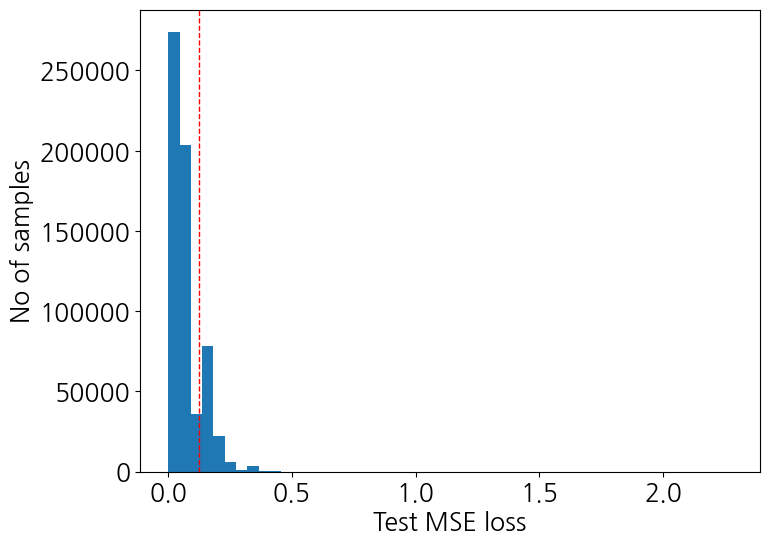

 test 데이터의 불량예측 개수:  118916


In [157]:
# 시각화
plt.figure(figsize=(8,6))
plt.hist(musad_test, bins=50)
plt.xlabel("Test MSE loss")
plt.ylabel("No of samples")
plt.axvline(best_threshold, color='red', linestyle='--', linewidth=1)
plt.show()
# test 데이터의 불량 갯수(임계치 기준)
test_Y_normal = [x > best_threshold for x in musad_test]
print(" test 데이터의 불량예측 개수: ", np.sum(test_Y_normal))

In [158]:
abnormal_df =abnormal_data.copy()
# 불필요한 변수 삭제
abnormal_df = abnormal_df.drop(['설비 이상신호'], axis=1)
abnomal_dataset = CustomDataset(abnormal_df)
abnomal_dataloader = DataLoader(abnomal_dataset, batch_size=64)
# 모두 비정상 값 복원오차 값 도출
Musad_abnormal,_,_ = testing(MUSADmodel, abnomal_dataloader)

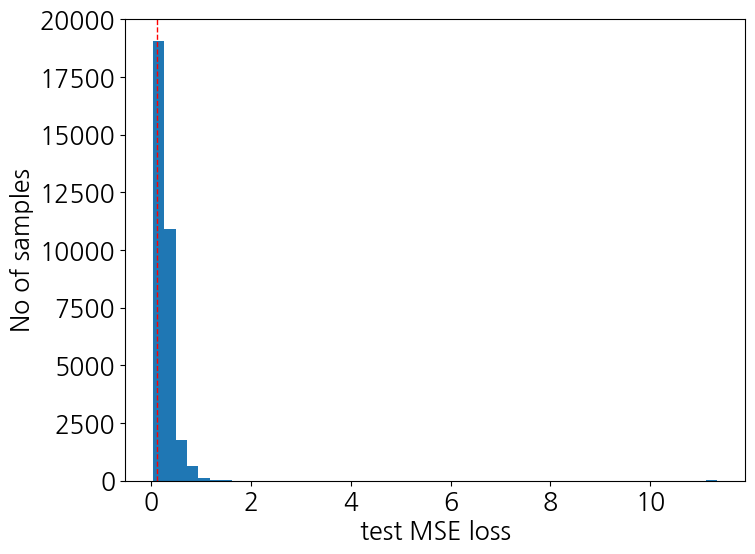

이상점으로 예측한 개수:  30299


In [159]:
# 모두 비정상인 값 예측
# 시각화
plt.figure(figsize=(8,6))
plt.hist(Musad_abnormal, bins=50)
plt.xlabel("test MSE loss")
plt.ylabel("No of samples")
plt.axvline(best_threshold, color='red', linestyle='--', linewidth=1)
plt.show()
# 이상점으로 판단한 데이터 확인
test_N_abnormal = [x > best_threshold for x in Musad_abnormal]
print("이상점으로 예측한 개수: ", np.sum(test_N_abnormal))

In [160]:
from sklearn.metrics import confusion_matrix
# 결과 값을 통한 정량적 지표 확인
# 실제 양품 불량으로 결합
true = np.concatenate([np.zeros(len(y_normal_test)), np.ones(len(abnormal_data))])
# 예측한 양품, 불량으로 결합
prediction = np.concatenate([test_Y_normal, test_N_abnormal])
musadpredict = prediction
# 혼동 행렬
confusion_matrix(true, prediction)

array([[507677, 118916],
       [  2376,  30299]])

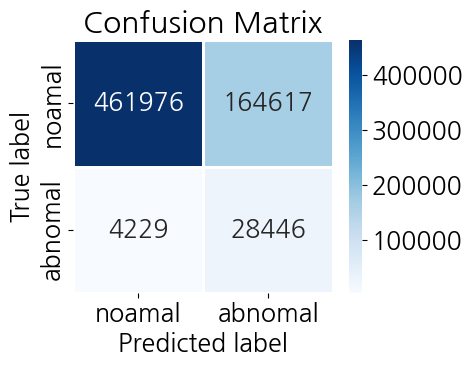

In [146]:
cm = confusion_matrix(true, prediction)
class_names=['정상','비정상']
fig = plt.figure(figsize=(5,4))
ax = sns.heatmap(cm, annot=True, cmap='Blues', linewidths=1, fmt="d",
 xticklabels=['noamal','abnomal'], yticklabels=['noamal','abnomal'])
ax.set(title='Confusion Matrix',
 ylabel='True label',
 xlabel='Predicted label')
plt.tight_layout()
plt.savefig('memAD_53.png')

In [62]:
from sklearn.metrics import classification_report
print(classification_report(true, prediction, target_names=['normal', 'abnormal']))

              precision    recall  f1-score   support

      normal       0.99      0.88      0.93    626593
    abnormal       0.26      0.84      0.40     32675

    accuracy                           0.88    659268
   macro avg       0.63      0.86      0.67    659268
weighted avg       0.95      0.88      0.91    659268



### idsaf

In [504]:
#musad_abnomal_in = pd.DataFrame(musad_abnomal_in)
#musad_abnormal_out = pd.DataFrame(musad_abnormal_out)
#musad_test_in = pd.DataFrame(musad_test_in)
#musad_test_out = pd.DataFrame(musad_test_out)


musad_abnomal_in.columns =  ['건조 1존 OP', '건조 2존 OP', '건조로 온도 1 Zone', '건조로 온도 2 Zone', '세정기',
       '소입1존 OP', '소입2존 OP', '소입3존 OP', '소입4존 OP', '소입로 CP 값', '소입로 CP 모니터 값',
       '소입로 온도 1 Zone', '소입로 온도 2 Zone', '소입로 온도 3 Zone', '소입로 온도 4 Zone',
       '솔트 컨베이어 온도 1 Zone', '솔트 컨베이어 온도 2 Zone', '솔트조 온도 1 Zone',
       '솔트조 온도 2 Zone']
musad_abnormal_out.columns =  ['건조 1존 OP', '건조 2존 OP', '건조로 온도 1 Zone', '건조로 온도 2 Zone', '세정기',
       '소입1존 OP', '소입2존 OP', '소입3존 OP', '소입4존 OP', '소입로 CP 값', '소입로 CP 모니터 값',
       '소입로 온도 1 Zone', '소입로 온도 2 Zone', '소입로 온도 3 Zone', '소입로 온도 4 Zone',
       '솔트 컨베이어 온도 1 Zone', '솔트 컨베이어 온도 2 Zone', '솔트조 온도 1 Zone',
       '솔트조 온도 2 Zone']
musad_test_in.columns =  ['건조 1존 OP', '건조 2존 OP', '건조로 온도 1 Zone', '건조로 온도 2 Zone', '세정기',
       '소입1존 OP', '소입2존 OP', '소입3존 OP', '소입4존 OP', '소입로 CP 값', '소입로 CP 모니터 값',
       '소입로 온도 1 Zone', '소입로 온도 2 Zone', '소입로 온도 3 Zone', '소입로 온도 4 Zone',
       '솔트 컨베이어 온도 1 Zone', '솔트 컨베이어 온도 2 Zone', '솔트조 온도 1 Zone',
       '솔트조 온도 2 Zone']
musad_test_out.columns =  ['건조 1존 OP', '건조 2존 OP', '건조로 온도 1 Zone', '건조로 온도 2 Zone', '세정기',
       '소입1존 OP', '소입2존 OP', '소입3존 OP', '소입4존 OP', '소입로 CP 값', '소입로 CP 모니터 값',
       '소입로 온도 1 Zone', '소입로 온도 2 Zone', '소입로 온도 3 Zone', '소입로 온도 4 Zone',
       '솔트 컨베이어 온도 1 Zone', '솔트 컨베이어 온도 2 Zone', '솔트조 온도 1 Zone',
       '솔트조 온도 2 Zone']

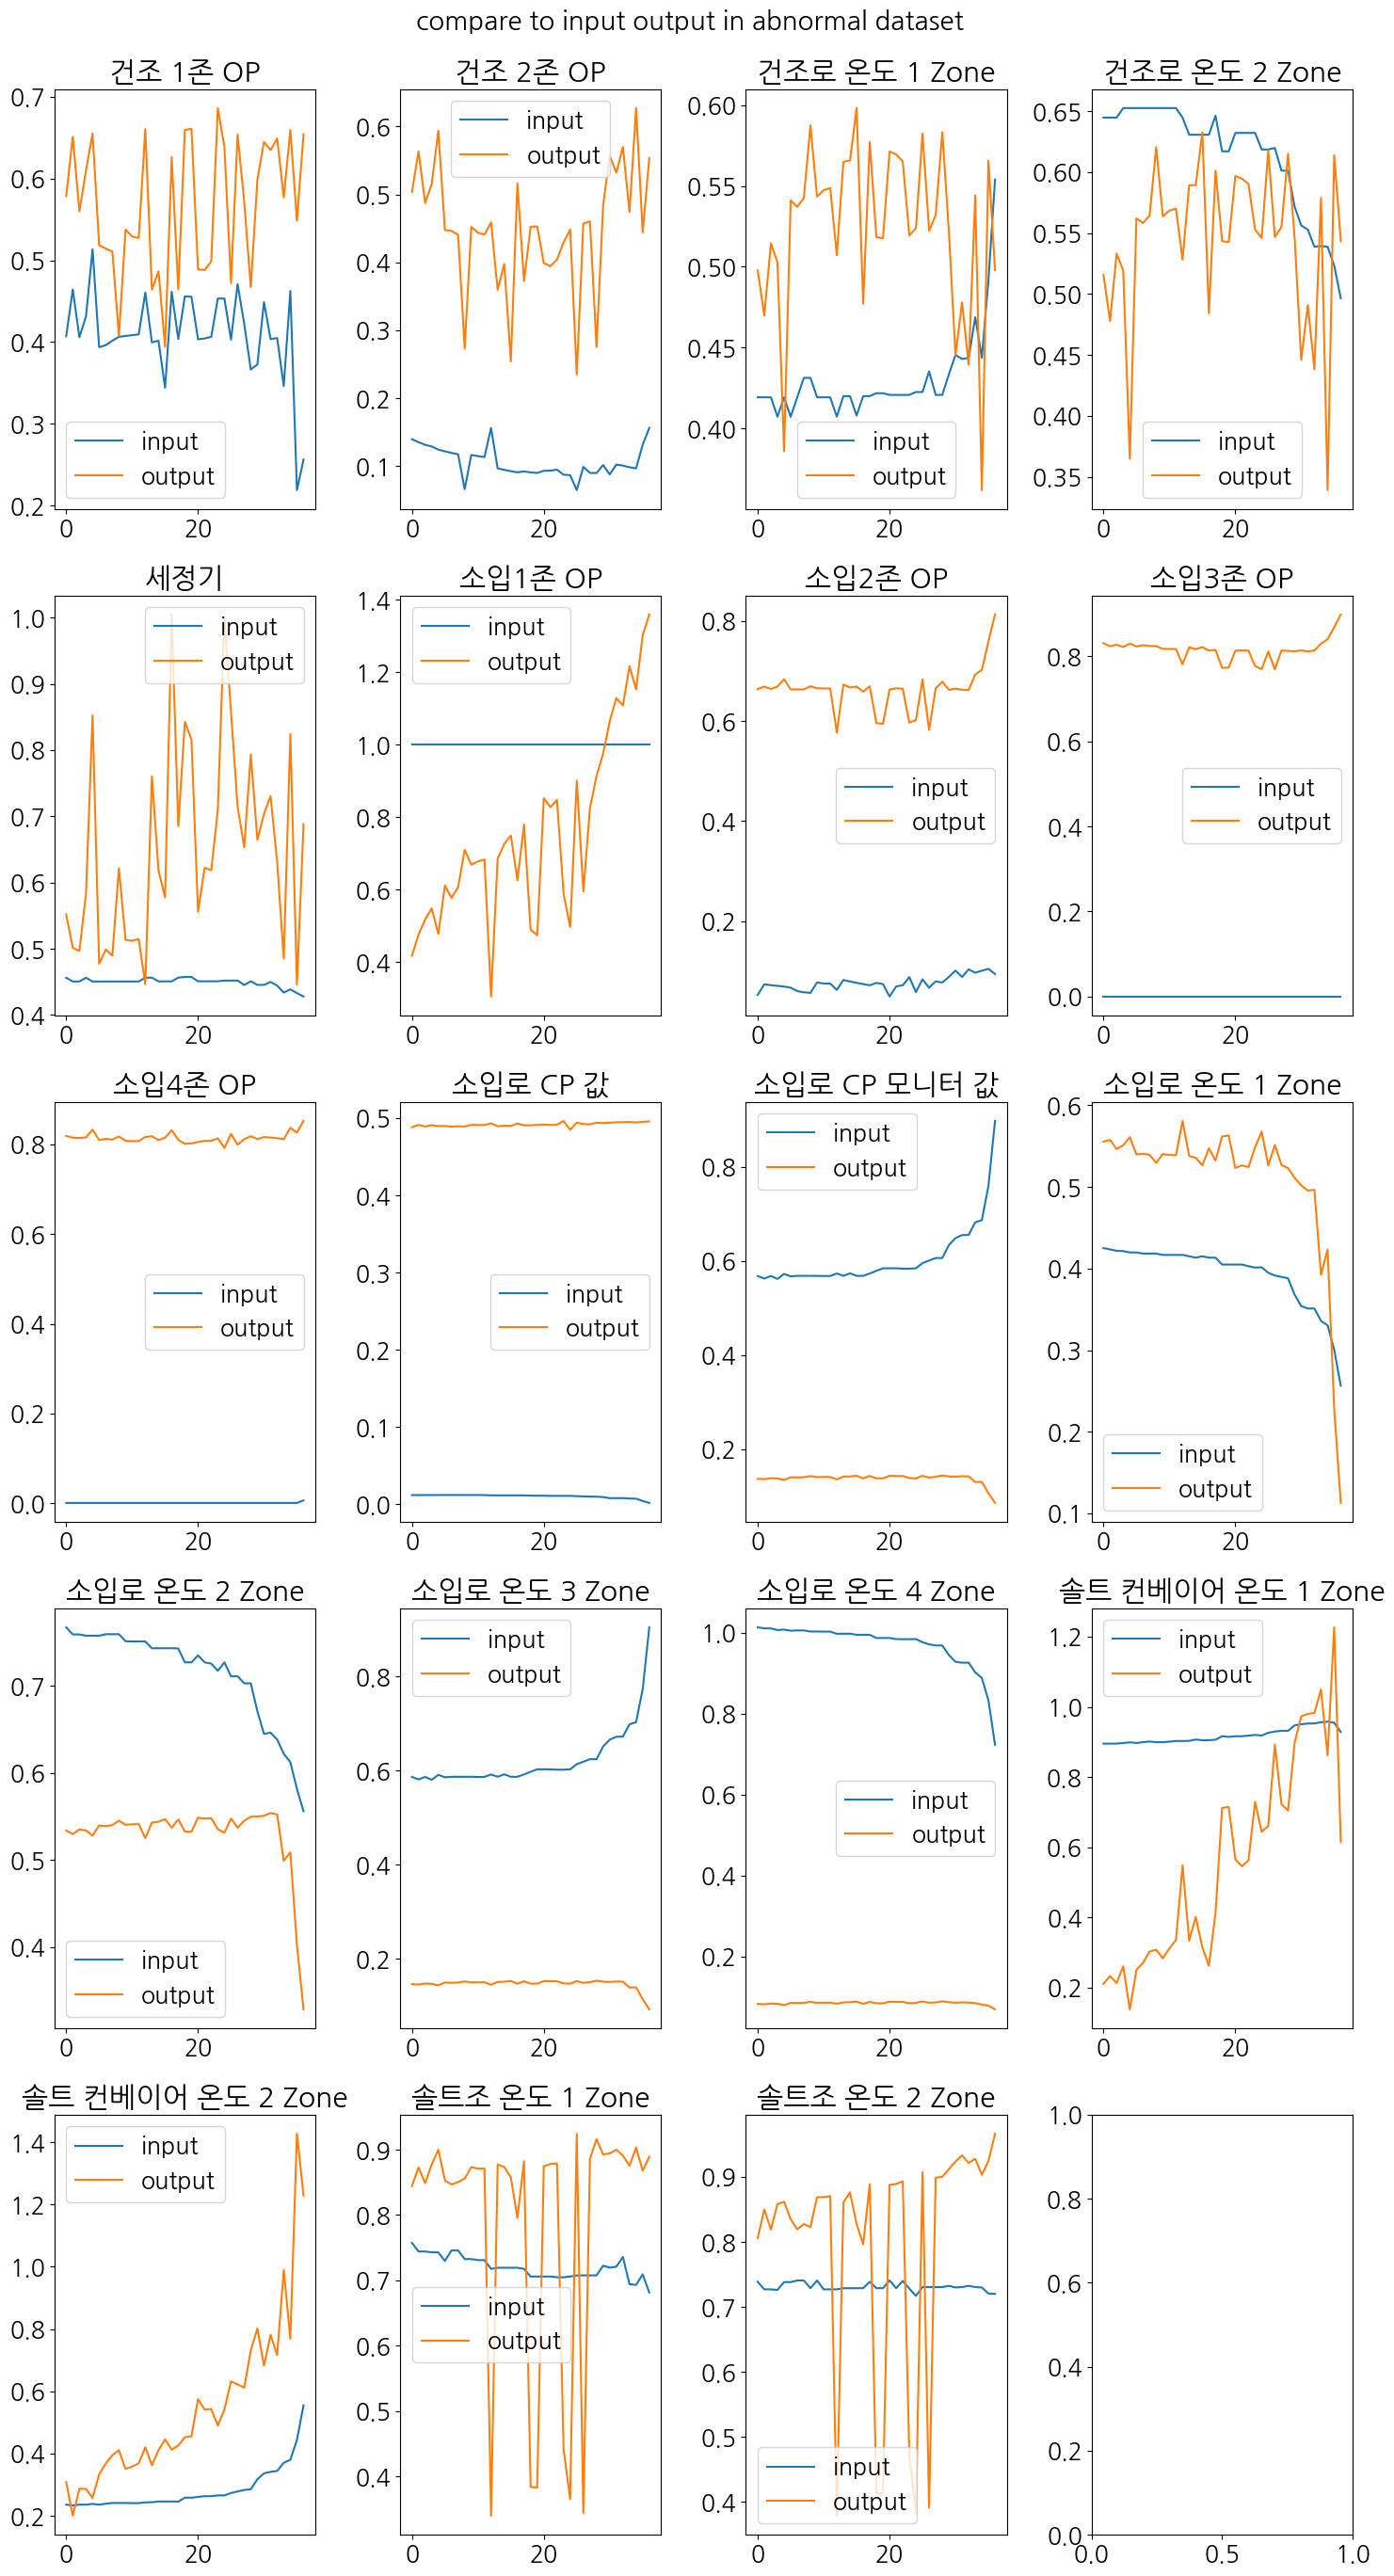

In [535]:
index = 0
fig, axs = plt.subplots(5, 4, figsize=(15, 28))  # 7x2 구조의 subplot 생성
plt.suptitle('compare to input output in abnormal dataset\n',fontsize=20)
for i in range(5):
    for j in range(4):
        if index == 19:
            break
        axs[i, j].plot(musad_abnomal_in[[musad_abnomal_in.columns[index]]], label='input')
        axs[i, j].plot(musad_abnormal_out[[musad_abnormal_out.columns[index]]], label='output')
        axs[i, j].legend()
        axs[i, j].set_title(mae_test_out.columns[index])
        index += 1

plt.tight_layout()
plt.savefig('abnomal_compare_all_feat.png')
plt.show()


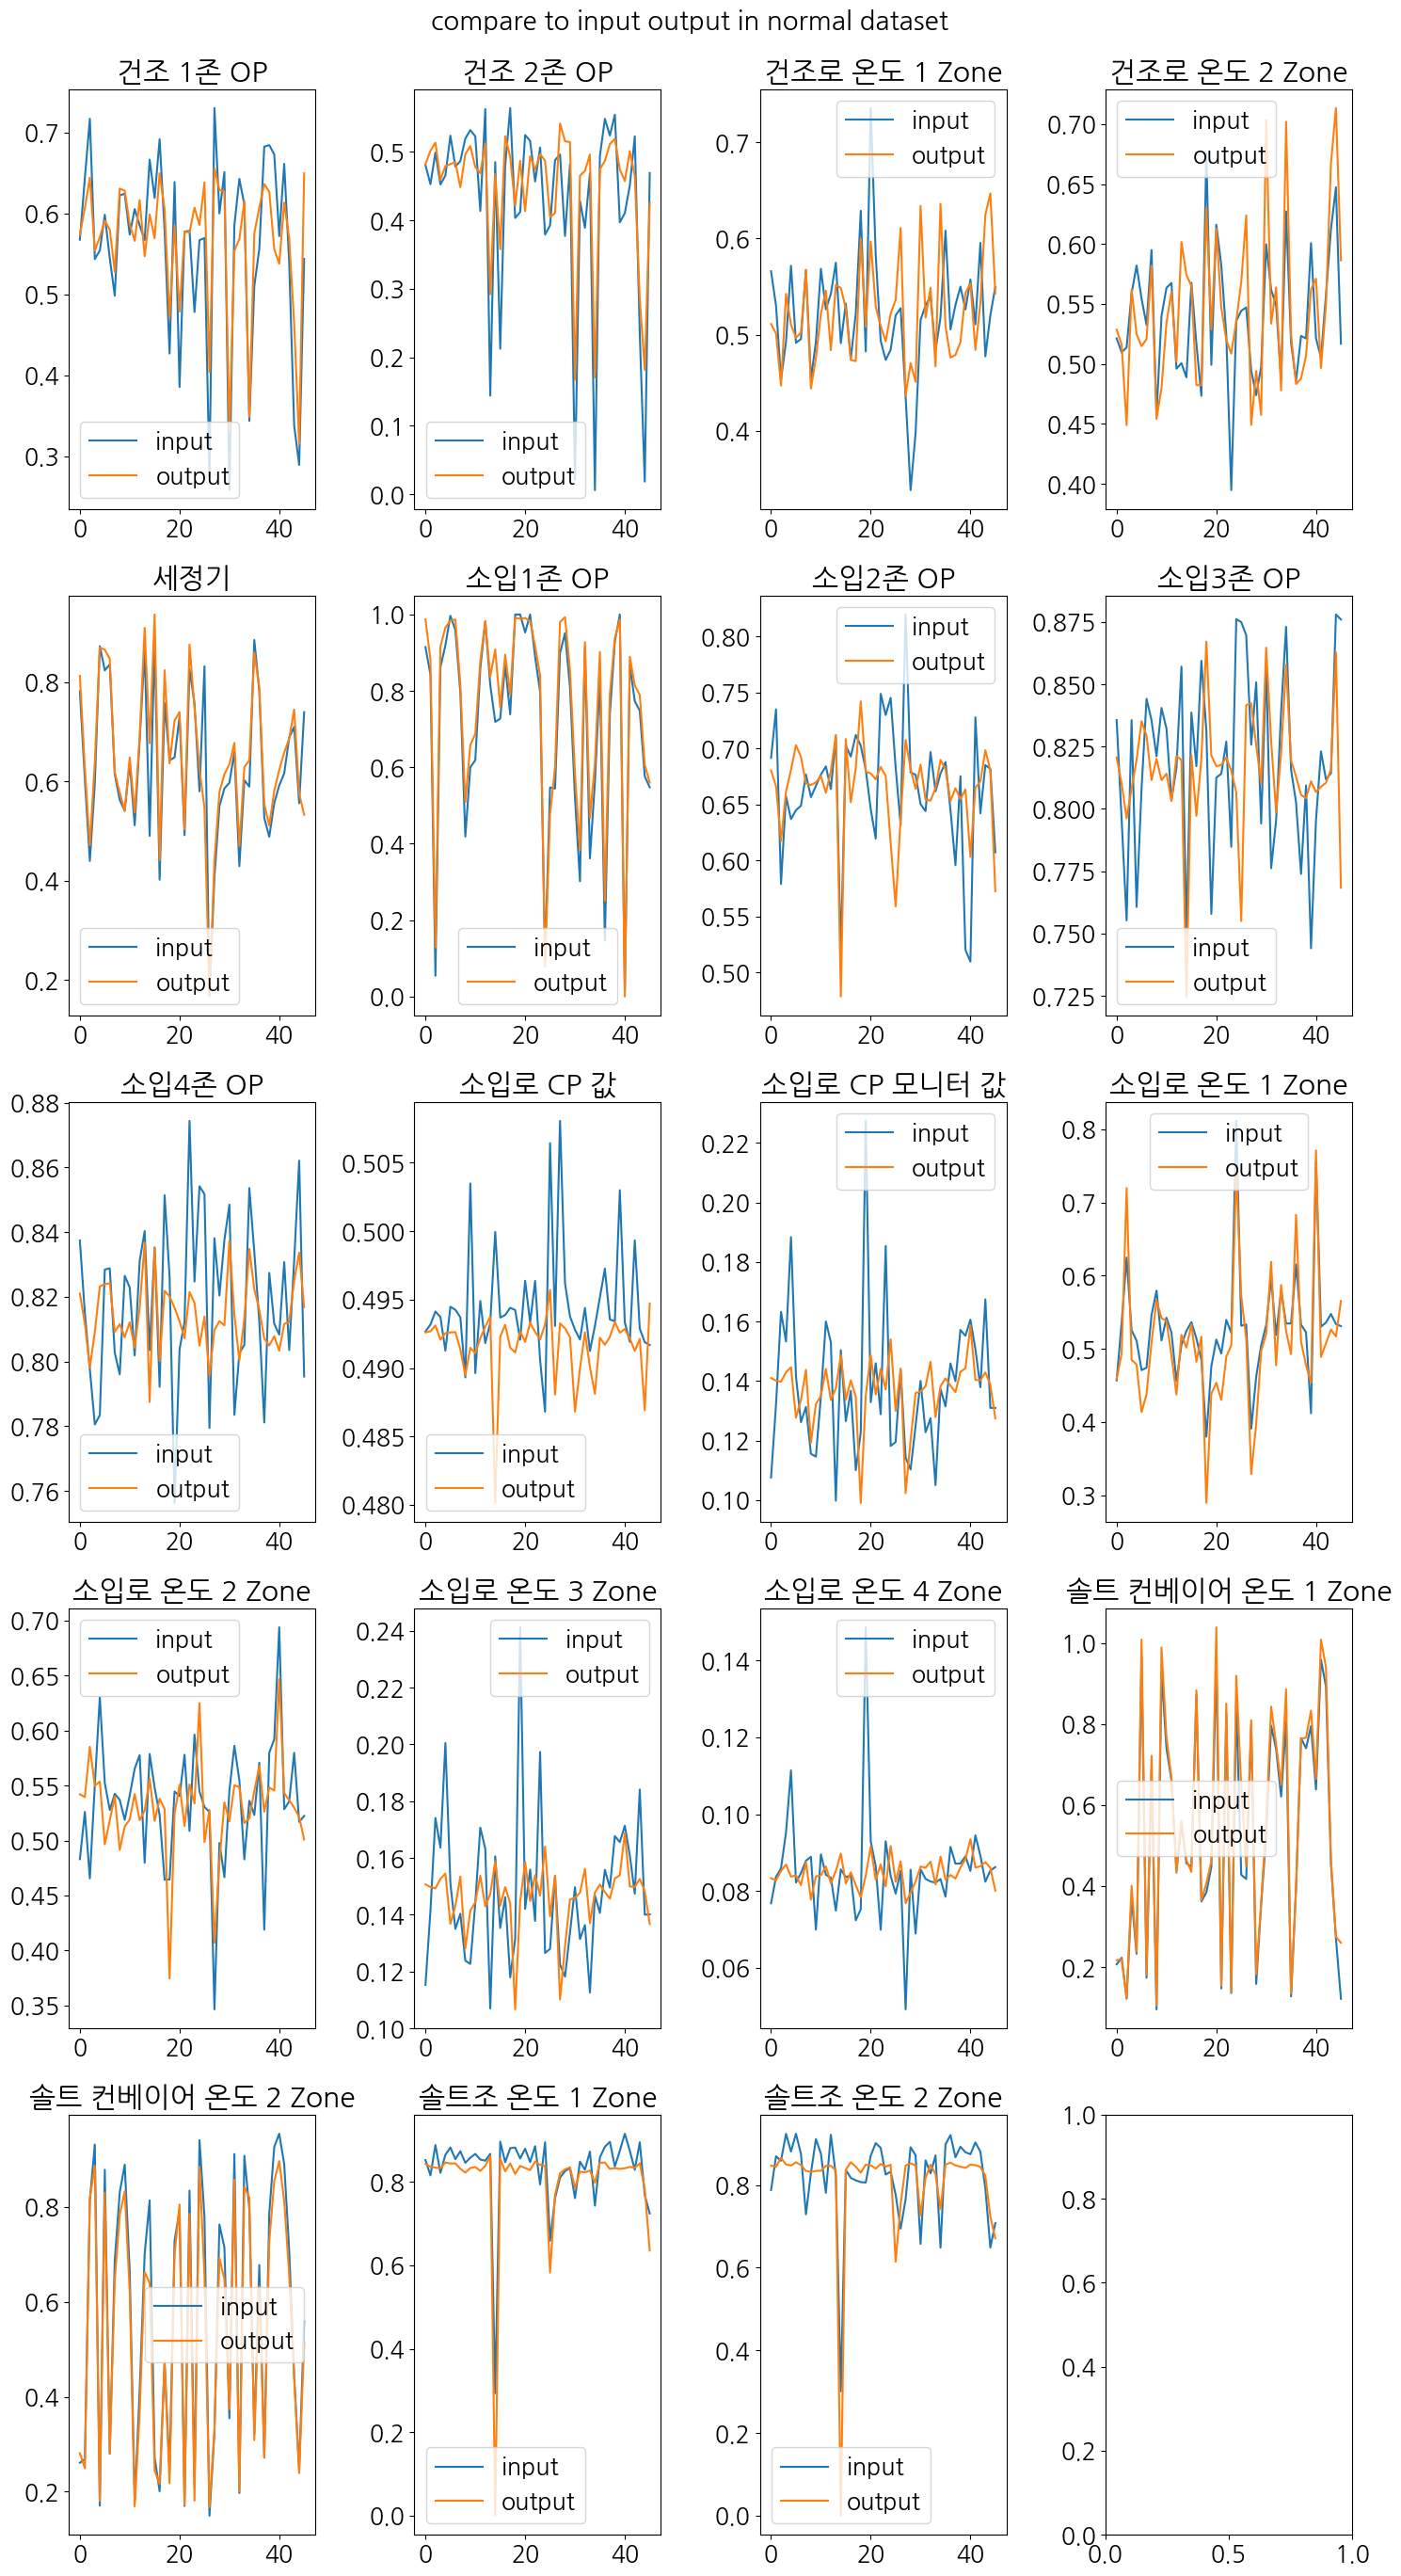

In [536]:
index = 0
fig, axs = plt.subplots(5, 4, figsize=(15, 28))  # 7x2 구조의 subplot 생성
plt.suptitle('compare to input output in normal dataset\n',fontsize=20)
for i in range(5):
    for j in range(4):
        if index == 19:
            break
        axs[i, j].plot(musad_test_in[[musad_test_in.columns[index]]], label='input')
        axs[i, j].plot(musad_test_out[[musad_test_out.columns[index]]], label='output')
        axs[i, j].legend()
        axs[i, j].set_title(mae_test_out.columns[index])
        index += 1

plt.tight_layout()
plt.savefig('nomal_compare_all_feat.png')
plt.show()


## ROC & PR

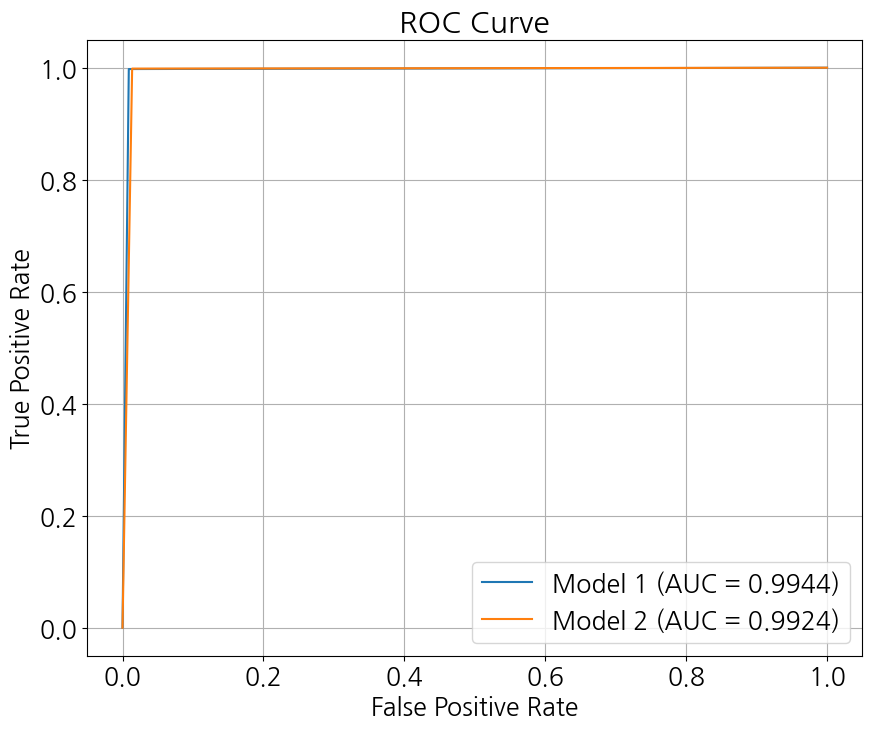

In [133]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# ROC 커브 계산
fpr1, tpr1, _ = roc_curve(true, aepredict)
fpr2, tpr2, _ = roc_curve(true, maepredict)

#fpr3, tpr3, _ = roc_curve(true, usadpredict)
#fpr4, tpr4, _ = roc_curve(true, musadpredict)

# ROC 커브 그리기
plt.figure(figsize=(10, 8))
plt.plot(fpr1, tpr1, label=f'Model 1 (AUC = {auc(fpr1, tpr1):.4f})')
plt.plot(fpr2, tpr2, label=f'Model 2 (AUC = {auc(fpr2, tpr2):.4f})')
#plt.plot(fpr3, tpr3, label=f'Model 3 (AUC = {auc(fpr3, tpr3):.4f})')
#plt.plot(fpr4, tpr4, label=f'Model 4 (AUC = {auc(fpr4, tpr4):.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

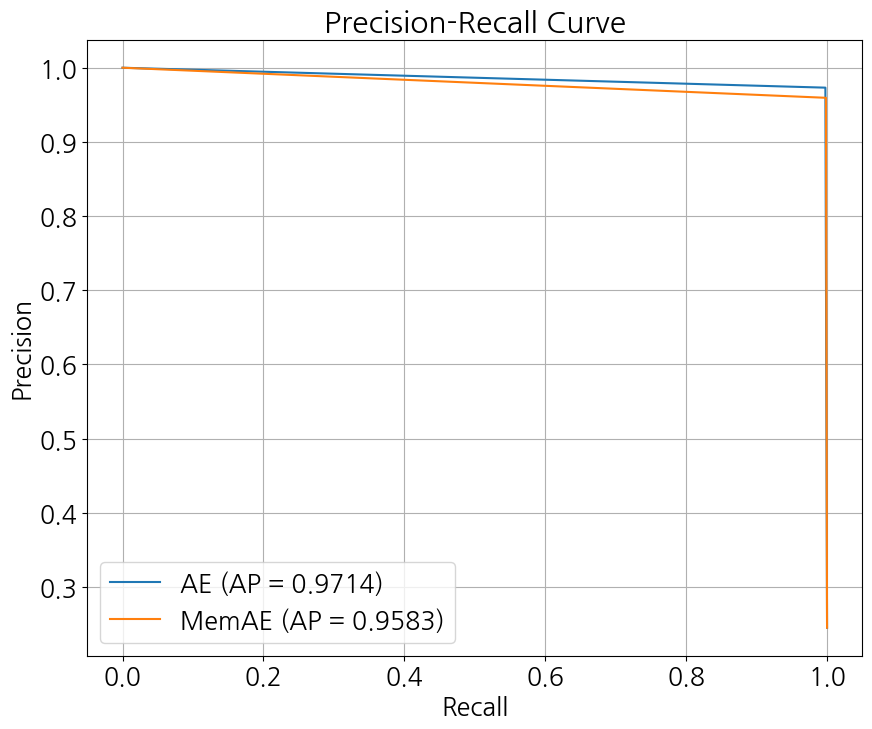

In [134]:
precision1, recall1, _ = precision_recall_curve(true, aepredict)
precision2, recall2, _ = precision_recall_curve(true, maepredict)
#precision3, recall3, _ = precision_recall_curve(true, usadpredict)
#precision4, recall4, _ = precision_recall_curve(true, musadpredict)

# PR 커브 그리기
plt.figure(figsize=(10, 8))
plt.plot(recall1, precision1, label=f'AE (AP = {average_precision_score(true, aepredict):.4f})')
plt.plot(recall2, precision2, label=f'MemAE (AP = {average_precision_score(true, maepredict):.4f})')
#plt.plot(recall3, precision3, label=f'AE + AD (AP = {average_precision_score(true, usadpredict):.4f})')
#plt.plot(recall4, precision4, label=f'MemAE + AD (AP = {average_precision_score(true, musadpredict):.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()
